# The Parity Problem
You are given a function as a black box: $ f: \{0, 1\}^n \rightarrow \{0, 1\}$ and $f(x) = u.x \mod2$.

For some hidden $u \in \{0, 1\}^n$, find $u$ with as few queries as possible. This is a restricted version of the Deutsch–Jozsa algorithm where instead of distinguishing between two different classes of functions, it tries to learn a string encoded in a function. 

## A classical solution

![Classical Solution](/images/bv.png "A classical solution the parity problem")

We need $n$ queries to compute the hidden string, because each time you run this circuit, you get only one bit of information. 
For example: let the hidden string $u = 101 $.

$$ f(100) = 1 $$ 

$$ f(010) = 0 $$

$$ f(001) = 1 $$

One possible solution to implement this classically is to use a classical AND gate as a mask to get each bit of information. 

## The Bernstein-Vazirani Algorithm
In contrast to the classical solution, the quantum solution requires only one query to find the hidden $u$. This algorithm was invented by Ethan Bernstein and Umesh Vazirani in 1992. Your task is to implement this algorithm in Q#. You can read more about the algorithm [here](https://en.wikipedia.org/wiki/Bernstein%E2%80%93Vazirani_algorithm).
![Quantum Solution](bv-q.PNG "A quantum solution the parity problem")

The Bernstein-Vazirani algorithm is described as follows:
1. Initialize n query qubits in the state $|0\rangle$ and one answer qubit in the state $|-\rangle$
2. Apply the Hadamard Transform to an n-qubit query state to get $H|0\rangle^{\otimes n} =  \frac{1}{2^{n/2}} \sum_x |x> $.
3. Apply the oracle $U_f$ which transforms the state to  $\frac{1}{2^{n/2}} \sum_x (-1)^{u.x} |x> $
4. Apply the Hadamard Transform to the query state after the oracle is applied.
5. Measure in the computational basis.

Original:  10110
Recovered: 10110


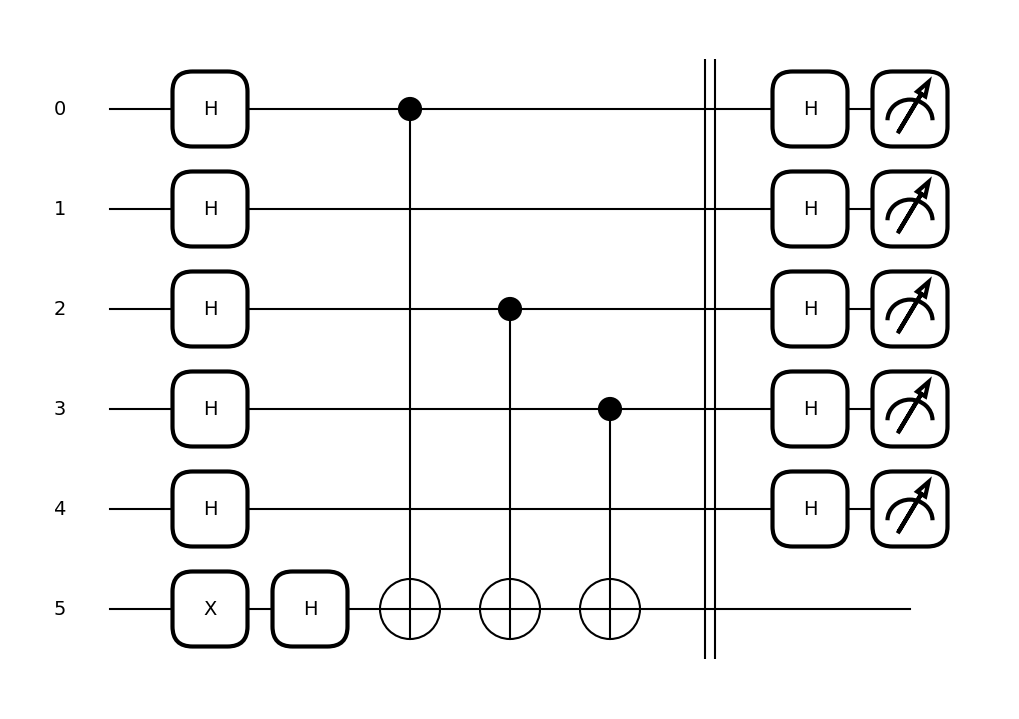

In [53]:
import random

import pennylane as qml
import matplotlib.pyplot as plt
import numpy as np

def init_dev(n):
    # initialize n query bits in state |0>, plus 1 answer qubit
    return qml.device('default.qubit', wires=n + 1)

def make_bv(n):
    dev = init_dev(n)

    @qml.qnode(dev)
    def bv(query_string=None):
        # set the last qubit to |->
        qml.X(wires=n)
        qml.H(wires=n)
        
        # do H|0>^{\otimes n} to put the query bits in superposition
        for i in range(n):
            qml.H(wires=i)

        # apply the oracle for the function f(x) = x_1 XOR x_2 XOR ... XOR x_n
        for i in range(n):
            if query_string is not None and query_string[i] == '1':
                qml.CNOT(wires=[i, n])

        qml.Barrier(wires=range(n + 1))

        # apply H|0>^{\otimes n} again to the query bits
        for i in range(n):
            qml.H(wires=i)

        

        return qml.probs(wires=range(n))

    return bv

if __name__ == '__main__':
    N = 5  # number of query bits
    query = ''.join(random.choice(['0', '1']) for _ in range(N))  # random query string of length N
    
    n = len(query)
    bv = make_bv(n)
    probs = bv(query_string=query)
    measured_index = np.argmax(probs)  # Find index with highest probability
    recovered_string = format(measured_index, f'0{n}b')  # Convert to binary with n bits
    print(f"Original:  {query}")
    print(f"Recovered: {recovered_string}")
    

    # show the circuit diagram
    fig, ax = qml.draw_mpl(bv, show_all_wires=True, wire_order=range(n + 1))(query_string=query)
    plt.show()
    

    # I didn't realize that I was supposed to build this thing incrementally below. I'll just do it again. 

## Task 1
**Summary**

Prepare qubits in a uniform superposition. For this, use [qml.broadcast](https://docs.pennylane.ai/en/stable/code/api/pennylane.broadcast.html), instead of a loop. This allows us to apply a unitary multiple times to a specific pattern of wires.

**Input**

*query_wires*: an array of numbers representing the query wires

Apply the hadamard transform the query_wires. 


In [36]:
# qml.broadcast is deprecated, so it looks like I'll have to use a for loop here. 

def walshHadamardTransform(query_wires):
    for i in query_wires:
        qml.H(wires=i)

## Task 2
**Summary**

Prepare the answer wire (traditionally, the last qubit on our device) in the state $|-\rangle$

**Input**

*answer_wire*: the answer qubit

In [37]:
def prepareAnswerQubit(answer_wire):
    qml.X(wires=answer_wire)
    qml.H(wires=answer_wire)

## Task 3

**Summary**

Encode the secret string (supplied as a boolean array s) into a function $U_f$

**Input**: 
query_wires: qubit array
answer_wire: answer qubit
secret: secret string as a boolean array e.g. [True, False, True, True]


In [38]:
def Uf(query_wires, answer_wire, secret):
    for i in range(len(secret)):
        if secret[i] == True:
            qml.CNOT(wires=[query_wires[i], answer_wire])

## Task 4: Explain what gates you applied to create the encoded string as $U_f$ and why you applied them.

The Bernstein-Vazirani oracle $U_f$ is designed to encode a secret string $u$ into the phase of a quantum state. It achieves this by evaluating the Boolean function $f(x) = u \cdot x \pmod 2$ and using the principle of phase kickback.

#### 1. Composing the Oracle (gates we applied to create $U_f$)

To build the oracle, we conditionally apply Controlled-NOT (CNOT) gates between the query register (the inputs) and a single answer wire (the target).

For every bit $i$ in the secret string $u$:

* If $u_i = 1$, we place a CNOT gate where the $i$-th query qubit is the control and the answer wire is the target.
* If $u_i = 0$, we do nothing.

#### 2. The Phase Kickback Mechanism (why we applied CNOT gates)

To leverage phase kickback, we must initialize the answer wire in the $|-\rangle$ state. When a CNOT gate acts on a target qubit in the $|-\rangle$ state, any state-flip on the target is mathematically equivalent to a phase-flip on the control qubit.

Mathematically, we define our generic initial state with the query register in a full superposition and the answer wire explicitly included:

$$|\psi_{initial}\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} |x\rangle \right) \otimes |-\rangle$$

When we apply the oracle $U_f$ to this combined state, the result is:

$$U_f |\psi_{initial}\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} (-1)^{f(x)} |x\rangle \right) \otimes |-\rangle$$

#### 3. Encoding the Secret String

By substituting the definition of our function $f(x)$, we see exactly how the secret string $u$ is encoded into the phase:

$$U_f |\psi_{initial}\rangle = \left( \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} (-1)^{u \cdot x \pmod 2} |x\rangle \right) \otimes |-\rangle$$

Where the bitwise dot product modulo 2 is defined as:


$$u \cdot x \pmod 2 = \left( \sum_{i=0}^{n-1} u_i x_i \right) \pmod 2$$

This reveals the core mechanism: the phase of a given basis state $|x\rangle$ is flipped (multiplied by $-1$) only if the overall parity of the bitwise dot product is odd. Because this phase shift is applied simultaneously across the entire superposition, a single query effectively evaluates the parity of the secret string against all possible inputs at once.


## Task 5: Run the Bernstein-Vazirani Algorithm using operations defined above

1. Create the secret string, and the required qubits
1. Perform the Bernstein Vazirani algorithm by using the tasks above. 
1. Return probabilities on the query_wires.


In [39]:
# Change the secret string to encode a string of your choice
secret_string = [False, False, False, True]

query_wires = range(len(secret_string))
answer_wire = len(secret_string)

dev = qml.device('default.qubit', wires=(len(secret_string) + 1)) # + 1 for the answer wire

In [40]:
@qml.qnode(dev)
def BernsteinVazirani(query_wires, answer_wire, secret_string):
    # Step 1: Prepare the answer qubit in the |-⟩ state
    prepareAnswerQubit(answer_wire)

    # Step 2: Apply the Walsh-Hadamard transform to the query wires
    walshHadamardTransform(query_wires)

    # Step 3: Apply the oracle U_f
    Uf(query_wires, answer_wire, secret_string)

    # Step 4: Apply the Walsh-Hadamard transform again to the query wires
    walshHadamardTransform(query_wires)

    # Step 5: Measure the query wires
    return qml.probs(wires=query_wires)

### Check whether your answer corresponds to the secret string

In [48]:
output = BernsteinVazirani(query_wires, answer_wire, secret_string)

In [52]:
measured_index = np.argmax(output)  # Find index with highest probability
num_query_bits = len(secret_string)   # or len(list(query_wires))
recovered_string = format(measured_index, f'0{num_query_bits}b')

print(f"Original:  {''.join(['1' if bit else '0' for bit in secret_string])}")
print(f"Recovered: {recovered_string}")

Original:  0001
Recovered: 0001
